## Utilizaremos 3 modelos alternativos para el pronóstico la accion de Tesla: ARIMA, Random Forest y red LSTM

In [51]:
# Se importan los paquetes

import yfinance as yf
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from tabulate import tabulate

In [52]:
# Se utiliza la API de Yahoo Finance para extraer los datos de los futuros de Soja

stock_symbol = 'TSLA'
start_date = '2011-01-01'
end_date = '2022-01-01'
data = yf.download(stock_symbol, start=start_date, end=end_date)

/tmp/ipykernel_1798/2204456460.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [53]:
data

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2011-01-03,1.774667,1.800000,1.726667,1.789333,19245000
2011-01-04,1.778000,1.796667,1.734667,1.777333,17811000
2011-01-05,1.788667,1.793333,1.746000,1.765333,21700500
2011-01-06,1.858667,1.866667,1.787333,1.788667,30918000
2011-01-07,1.882667,1.905333,1.860000,1.866667,33718500
...,...,...,...,...,...
2021-12-27,364.646667,372.333344,356.906677,357.890015,71145900
2021-12-28,362.823334,373.000000,359.473328,369.829987,60324000


## Se visualiza la serie

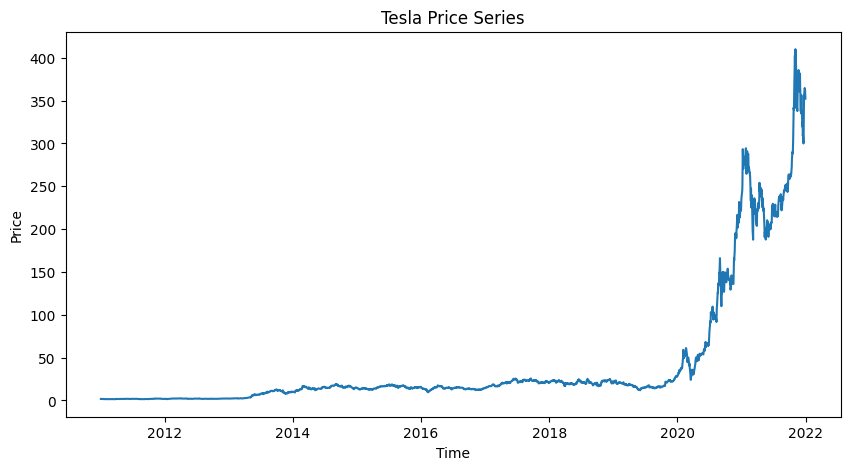

In [54]:
# Plot the price series
plt.figure(figsize=(10, 5))
plt.plot(data['Close'])
plt.title("Tesla Price Series")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Se aplica el test ADF para verificar si la serie es o no estacionaria

In [55]:
def adf_test_with_alternatives(series, title=""):
    print(f"\n{title}\n{'-' * 50}")

    # No constant (default regression='n')
    result_nc = adfuller(series, regression='n')
    print("No Constant:")
    print(f"ADF Statistic: {result_nc[0]}")
    print(f"p-value: {result_nc[1]}")
    print(f"Critical Values: {result_nc[4]}")

    # Constant (default regression='c')
    result_c = adfuller(series, regression='c')
    print("\nConstant:")
    print(f"ADF Statistic: {result_c[0]}")
    print(f"p-value: {result_c[1]}")
    print(f"Critical Values: {result_c[4]}")

    # Constant and trend (regression='ct')
    result_ct = adfuller(series, regression='ct')
    print("\nConstant and Trend:")
    print(f"ADF Statistic: {result_ct[0]}")
    print(f"p-value: {result_ct[1]}")
    print(f"Critical Values: {result_ct[4]}")

# Run ADF tests for the price series
adf_test_with_alternatives(data['Close'], title="Price Series")


Price Series
--------------------------------------------------
No Constant:
ADF Statistic: 2.936345601378141
p-value: 0.9997304575138881
Critical Values: {'1%': np.float64(-2.5665561704632225), '5%': np.float64(-1.9410984398023796), '10%': np.float64(-1.6167234610629704)}

Constant:
ADF Statistic: 2.3407146742644525
p-value: 0.9989796196797777
Critical Values: {'1%': np.float64(-3.4327379732269048), '5%': np.float64(-2.862595034666578), '10%': np.float64(-2.567331628897652)}

Constant and Trend:
ADF Statistic: 0.9355609524165606
p-value: 1.0
Critical Values: {'1%': np.float64(-3.9620766359917874), '5%': np.float64(-3.4120929560913575), '10%': np.float64(-3.127993828871924)}


## Se obtiene la serie de retornos, y ve vuelve a calcular el test ADF

In [56]:
# Se obtienen las series de retornos

close_prices = data['Close'].values.reshape(-1, 1)
returns = pd.DataFrame(close_prices).pct_change().dropna()
returns.shape

(2768, 1)

In [57]:
print("{:.10f}".format(np.mean(returns)))

0.0025150641


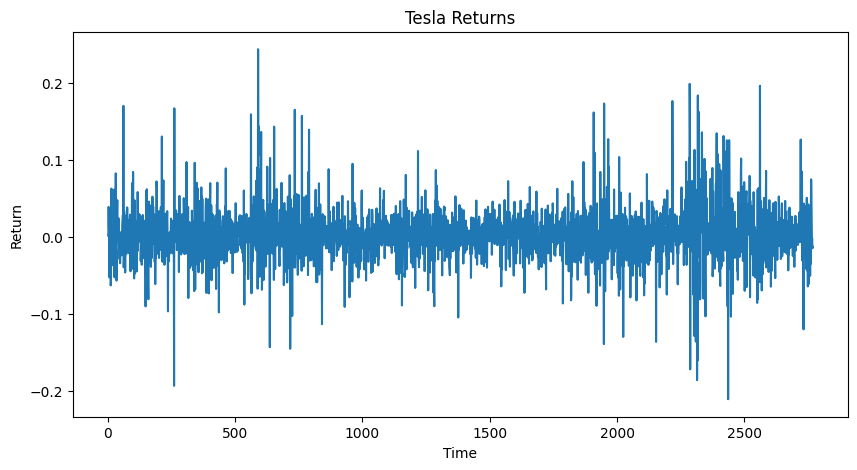

In [58]:
# Plot the returns series
plt.figure(figsize=(10, 5))
plt.plot(returns)
plt.title("Tesla Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

In [59]:
# ADF Test on Returns
adf_test_with_alternatives(returns, title="Return Series")


Return Series
--------------------------------------------------
No Constant:
ADF Statistic: -52.647899341964006
p-value: 0.0
Critical Values: {'1%': np.float64(-2.5665484968579424), '5%': np.float64(-1.9410975106759865), '10%': np.float64(-1.6167243648474336)}

Constant:
ADF Statistic: -52.913839142137654
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4327155138680454), '5%': np.float64(-2.8625851157957265), '10%': np.float64(-2.5673263480950106)}

Constant and Trend:
ADF Statistic: -52.92639709719018
p-value: 0.0
Critical Values: {'1%': np.float64(-3.962045529983771), '5%': np.float64(-3.412077882745579), '10%': np.float64(-3.1279849553403984)}


## Podemos apreciar que el retorno es estacionario, y es la variable que intentaremos pronosticar con los distintos modelos

## Se dividen los datos en conjunto de entrenamiento y testeo para utilizar el modelo ARMA

In [60]:
train = returns[0:int(0.8*len(returns))]
test = returns[len(train):]

print("Length of Train Data: ", len(train))
print("Length of Test Data: ", len(test))

Length of Train Data:  2214
Length of Test Data:  554


In [61]:
model = ARIMA(train, order = (2, 0, 2))
arima_model = model.fit()
arima_model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                 2214
Model:                 ARIMA(2, 0, 2)   Log Likelihood                4520.134
Date:                Tue, 03 Mar 2026   AIC                          -9028.268
Time:                        14:49:14   BIC                          -8994.052
Sample:                             0   HQIC                         -9015.769
                               - 2214                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      2.262      0.024       0.000       0.003
ar.L1         -0.0105      2.874     -0.004      0.997      -5.644       5.622
ar.L2         -0.0066      1.556     -0.004      0.997      -3.056       3.043
ma.L1         -0.0104      2.874     -0.004      0.997      -5.643       5.623
ma.L2         -0.0067      1.612     -0.004      0.997      -3.165       3.152
sigma2         0.0010   1.53e-05     64.293      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3557.18
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             0.52
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Con este modelo, se realizan predicciones de un paso hacia adelante para el conjunto de testeo. Se realizan los plots correspondientes y se calcula el error cuadrático medio

In [62]:
# Extract AR and MA coefficients and residuals
ar_params = arima_model.arparams  # AR coefficients (phi)
ma_params = arima_model.maparams  # MA coefficients (theta)
residuals = arima_model.resid  # Residuals from training

# Manual one-step-ahead forecast
test_predictions = []
history = train.iloc[:, 0].tolist()  # Initialize history with scalar values from train
epsilon_history = list(residuals)  # Start with residuals from training

for t in range(len(test)):
    # Compute AR part: sum of phi * lagged values
    ar_part = sum(ar_params[i] * history[-i - 1] for i in range(len(ar_params)))

    # Compute MA part: sum of theta * lagged residuals
    ma_part = sum(ma_params[i] * epsilon_history[-i - 1] for i in range(len(ma_params)))

    # Forecast value
    forecast = ar_part + ma_part
    test_predictions.append(forecast)

    # Update history and residuals
    actual = test.iloc[t, 0] # Extract scalar value from test
    error = actual - forecast  # Residual for this step
    history.append(actual)
    epsilon_history.append(error)

# Convert predictions to a Series
test_predictions = pd.Series(test_predictions, index=data.index[-len(test):])

# Evaluate the predictions
mse_arma = mean_squared_error(test, test_predictions)
print(f"Mean Squared Error on Test Set: {mse_arma}")

Mean Squared Error on Test Set: 0.0021453080027886836


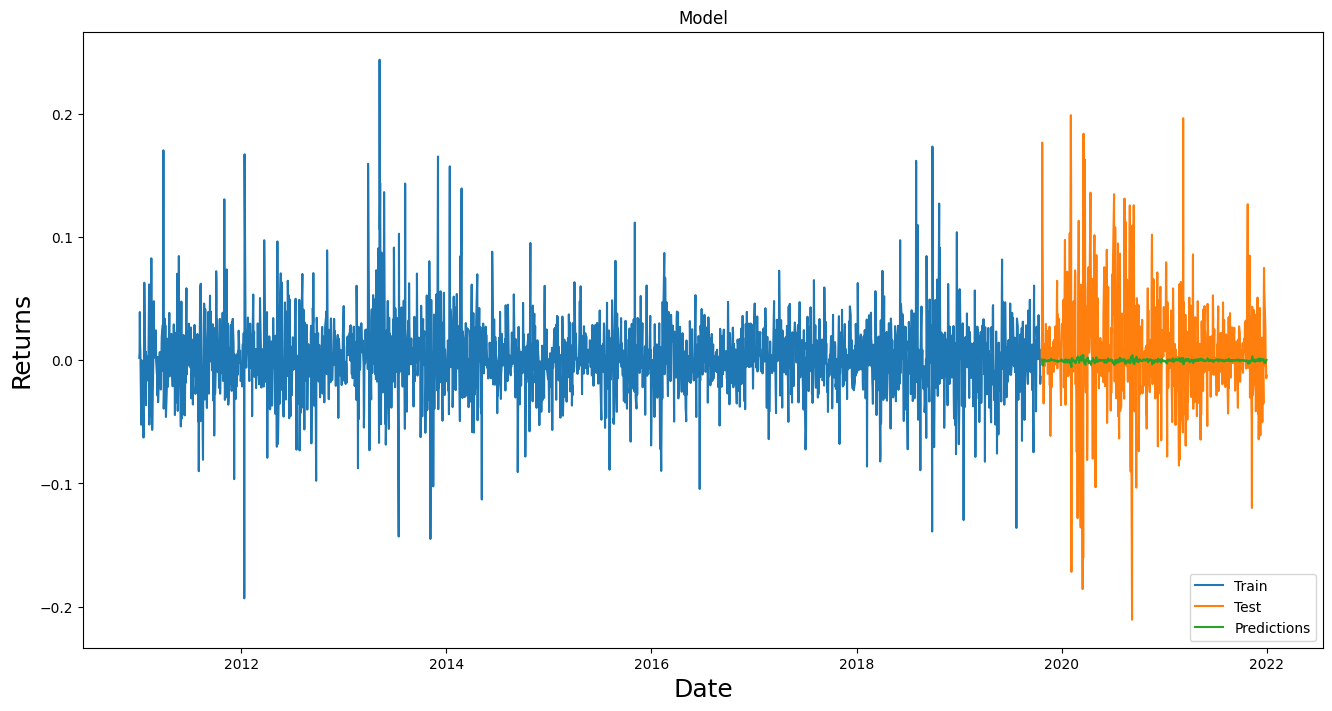

In [63]:
#plot the data
y_train = pd.DataFrame(train)
y_train.index = data.index[:len(train)]
y_test = pd.DataFrame(test)
y_test.index = data.index[-len(test):]
predicted = pd.DataFrame(test_predictions)
predicted.index = y_test.index


#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Returns', fontsize=18)
plt.plot(y_train)
plt.plot(y_test)
plt.plot(predicted)
plt.legend(['Train', 'Test', 'Predictions'], loc='lower right')
plt.show()

## Utilizamos una red neuronal

## En particular, utilizamos la arquitectura LSTM para estimar el retorno de la soja

In [64]:
# Se estandarizan los datos de retornos usando el StandardScaler

scaler = StandardScaler()
returns = scaler.fit_transform(returns)

In [65]:
# Se define la función para crear los datasets a ser utilizados por la red LSTM

def create_lstm_data(data, time_steps=1):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)

In [66]:
# Se utilizan 100 timestamps para predecir el siguiente

time_steps = 100
x, y = create_lstm_data(returns, time_steps)
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

In [67]:
x[0]

array([[-1.82885391e-02],
       [ 1.00040313e-01],
       [ 1.05141473e+00],
       [ 2.98522113e-01],
       [ 1.41294752e-01],
       [-1.57590496e+00],
       [-7.22107320e-02],
       [-8.60274681e-01],
       [-5.86861725e-01],
       [-1.94873913e-01],
       [-1.87505857e+00],
       [-1.75689279e+00],
       [ 4.60890065e-01],
       [ 1.73471128e+00],
       [ 1.50529269e-01],
       [ 9.22774482e-03],
       [ 1.24992129e-01],
       [-1.12064479e+00],
       [ 3.54124895e-02],
       [-2.98572267e-01],
       [-3.61869933e-02],
       [-4.43999573e-01],
       [-2.78760532e-01],
       [-5.49508793e-01],
       [ 1.69502621e+00],
       [-1.57285207e+00],
       [-5.98347664e-02],
       [-3.51165204e-02],
       [-2.82136361e-01],
       [-3.70766653e-01],
       [ 2.30363390e+00],
       [-1.38414026e+00],
       [-5.83174399e-01],
       [-1.69480298e+00],
       [-1.24728964e-01],
       [ 8.48450828e-01],
       [ 1.30409660e+00],
       [ 2.68293165e-01],
       [-1.2

In [68]:
y[0]

np.float64(-0.004030509475677578)

In [69]:
# Se forma el conjunto de entrenamiento con el 80% inicial de los datos, y el restante 20% para testearlo

threshold = len(train)-100
train_x = x[0:threshold]
test_x = x[threshold:]
train_y = y[0:threshold]
test_y = y[threshold:]

In [70]:
print(len(test_x))

554


In [71]:
# Se construye la estructura de la red LSTM, que tendrá 50 neuronas en cada capa

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.fit(train_x, train_y, epochs=10, batch_size=25)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.8411
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.8879
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.8677
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.8090
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.8361
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.7398
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.8086
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.8007
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.8140
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.8096


In [73]:
predicted_returns = model.predict(test_x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


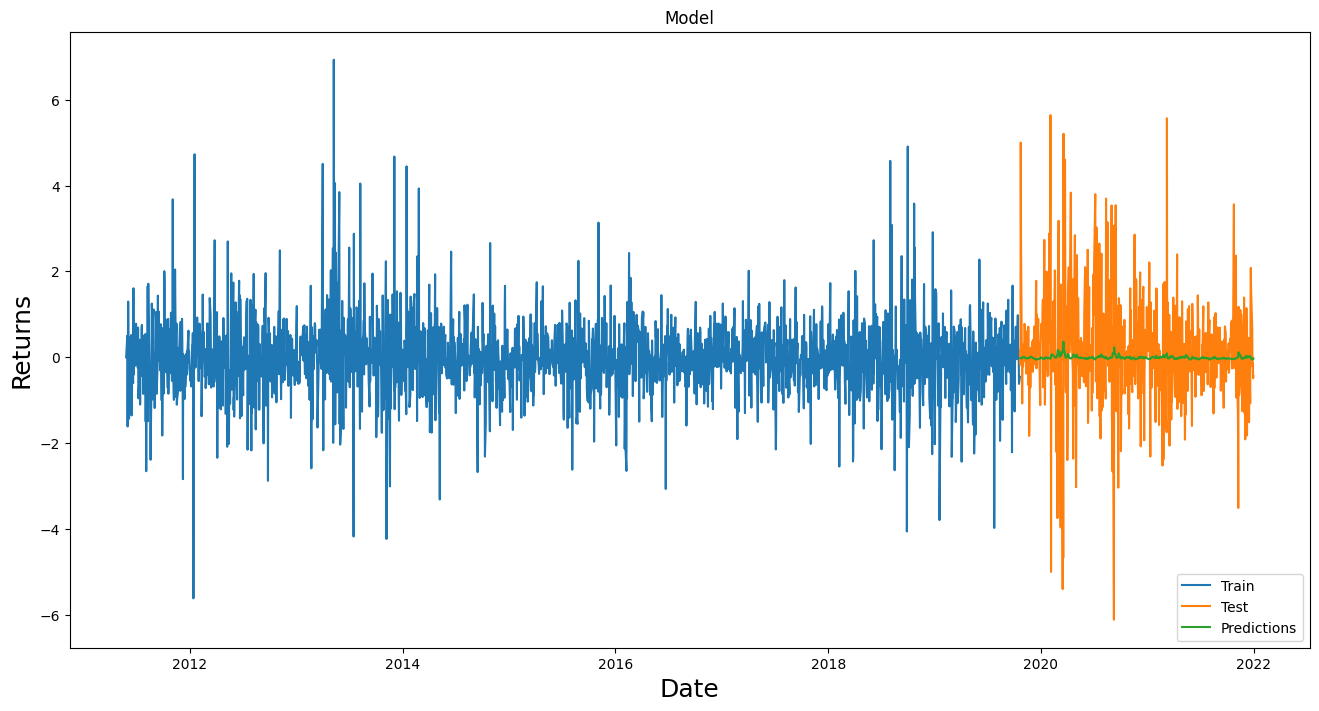

In [74]:
# Una vez entrenado el modelo y obtenidas las predicciones, se lo compara con los datos reales

#plot the data
y_train = pd.DataFrame(train_y)
y_train.index = data.index[101:threshold+101]
y_test = pd.DataFrame(test_y)
y_test.index = data.index[threshold+101:]
predicted = pd.DataFrame(predicted_returns)
predicted.index = y_test.index


#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Returns', fontsize=18)
plt.plot(y_train)
plt.plot(y_test)
plt.plot(predicted)
plt.legend(['Train', 'Test', 'Predictions'], loc='lower right')
plt.show()

In [75]:
mse_lstm = mean_squared_error(test_y, predicted_returns)
mean_squared_error(test_y, predicted_returns)

1.74265260579948

## Finalmente, aplicamos el modelo de Random Forest

## Utilizaremos 100 rezagos del retorno de la soja como predictores

In [76]:
# transform a time series dataset into a supervised learning dataset
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape
    df = pd.DataFrame(data)
    cols = list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    # put it all together
    agg = pd.concat(cols, axis=1)
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg.values

In [77]:
data_rf = series_to_supervised(returns, 100, 1)
data_rf

array([[-0.01828854,  0.10004031,  1.05141473, ...,  2.35622118,
         0.42314733, -0.00403051],
       [ 0.10004031,  1.05141473,  0.29852211, ...,  0.42314733,
        -0.00403051,  0.50103662],
       [ 1.05141473,  0.29852211,  0.14129475, ..., -0.00403051,
         0.50103662, -1.61541791],
       ...,
       [-0.69615077,  0.52985866, -0.2238607 , ...,  0.65270313,
        -0.21577508, -0.13235256],
       [ 0.52985866, -0.2238607 , -0.15996268, ..., -0.21577508,
        -0.13235256, -0.49117357],
       [-0.2238607 , -0.15996268,  0.51311278, ..., -0.13235256,
        -0.49117357, -0.43594948]])

## Se divide el dataset en conjunto de entrenamiento y de testeo

In [78]:
# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
    return data[:n_test, :], data[n_test:, :]

In [79]:
train_rf, test_rf = train_test_split(data_rf, len(train)-100)

In [80]:
test_rf.shape

(554, 101)

In [81]:
X_train_rf, y_train_rf = train_rf[:, :-1], train_rf[:, -1]
X_test_rf, y_test_rf = test_rf[:, :-1], test_rf[:, -1]

## Finalmente, corremos el modelo, realizamos las predicciones y obtenemos el error cuadrático medio

In [82]:
# fit model
model_rf = RandomForestRegressor(n_estimators=500, max_features="sqrt")
model_rf.fit(X_train_rf, y_train_rf)

RandomForestRegressor(max_features='sqrt', n_estimators=500)

In [83]:
rf_predict = model_rf.predict(X_test_rf)

In [84]:
print("\nTest Data:\nMean Square Error: {}".format(mean_squared_error(rf_predict, y_test_rf)))
mse_rf = mean_squared_error(rf_predict, y_test_rf)


Test Data:
Mean Square Error: 1.7410377015160858


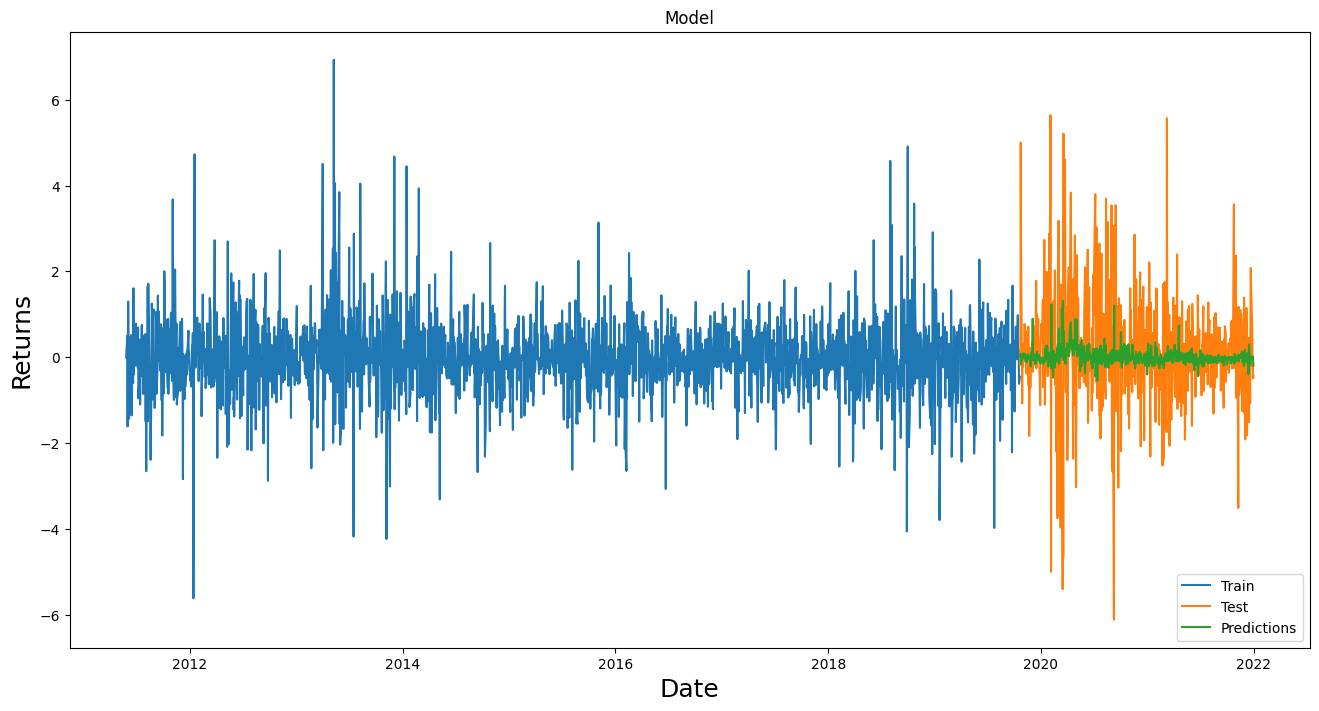

In [85]:
# Una vez entrenado el modelo y obtenidas las predicciones, se lo compara con los datos reales

#plot the data
y_train = pd.DataFrame(y_train_rf)
y_train.index = data.index[101:threshold+101]
y_test = pd.DataFrame(y_test_rf)
y_test.index = data.index[threshold+101:]
predicted = pd.DataFrame(rf_predict)
predicted.index = y_test.index


#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Returns', fontsize=18)
plt.plot(y_train)
plt.plot(y_test)
plt.plot(predicted)
plt.legend(['Train', 'Test', 'Predictions'], loc='lower right')
plt.show()

## Finalmente, se compara el error cuadrático medio de los modelos

In [86]:
# Define the MSE values for each model
model_results = {
    "Model": ["ARMA(2,2)", "Random Forest", "LSTM"],
    "MSE": [mse_arma, mse_rf, mse_lstm]  # Replace these values with your actual MSEs
}

# Create a DataFrame
df_results = pd.DataFrame(model_results)

# Display the table in a nice format
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════╤════════════╕
│    │ Model         │        MSE │
╞════╪═══════════════╪════════════╡
│  0 │ ARMA(2,2)     │ 0.00214531 │
├────┼───────────────┼────────────┤
│  1 │ Random Forest │ 1.74104    │
├────┼───────────────┼────────────┤
│  2 │ LSTM          │ 1.74265    │
╘════╧═══════════════╧════════════╛
